# Comparison between methodology (new equations) and previous equations
### Connor van Wieren, 2025

In [1]:
from datetime import datetime
from IPython.display import display, Markdown
todays_date = str(datetime.now())[:16] # limit to minutes
display(Markdown(f'### Date: {todays_date}'))

### Date: 2025-04-15 20:54

**Figures:**
1. Figure showing the difference between model outpouts with transport of proxy on and off (basically a finalized version of a figure that I've made before)

## Imports

In [4]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
#from pypalettes import load_cmap # for color palettes
import jax
import jax.numpy as jnp
from jax import  jit, random, lax, vmap
from jax.scipy.integrate import trapezoid as trapz
jax.config.update('jax_platform_name', 'cpu')
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
from matplotlib.lines import Line2D
from cycler import cycler
import seaborn as sns
import pandas as pd 
import time
import os
import scipy
from scipy import signal
from scipy.stats import norm, uniform, gaussian_kde
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
import rasterio
import pickle
import dill
import sys
import string

# load funcs from .py files
sys.path.insert(0, '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport')
from model_dev import run
from utils import *
from output import Model_output
from bahamas import load_geyman_bahamas

# import facies
sys.path.insert(0, '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/notebooks/')
from facies import facies

# interactive plots
from ipywidgets import interactive, interact
from IPython.display import clear_output, Video

np.set_printoptions(threshold=np.inf,linewidth=np.inf)

fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/figures/'
sem_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Talks/UVic_Department_Talks/Exit Seminar/img/' # for exit seminar
tex_fig_dir = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Publications/Ch2_Paleozoic_CIE_EPSL/img/'
data = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/Paleozoic_CIEs/data/'

## Model parameters

In [5]:
# from the current method
params = {'Nx':400,        # was 200; 400
          'xmin':0,
          'xmax':6000,     # was 180, scaled up, just need to change slope of hi
          'dx':0.8, #'none',     # 0.1 # if none defaults to (xmax-xmin)/(Nx); 0.8
          'start':0,
          'dt':0.1,
          'total_n':2000,
          'compiled_steps':100,
          'pel_epsilon':0,   # ‰; 1.5
          'alg_epsilon':0,
          'coral_epsilon':0,
          'ocean_depth':0,  # depth at which seawater reflects open ocean
          'marine_K':2.5e-1,   # 1e-2; 1.5e-1
          'land_K':5e-1,   # 2e-2; 2.5e-1
          'smooth_K':6,      # was 10; the lower it is the more of a sharp step function it is
          'ylen':1000,       # 10000; I really don't think it needs to be this big
          'A':0.1}             # 0.01 0.1, I think needs to be smaller to scale with small magnitude of this run's topography changes
                             # A needs to be tuned. If A too big or too small, model provides unrealistic or incorrect functionality

# build time and space constraints for initial condition setting and initiation functions (sl, growth, etc.)
x,t,end = init_vars(params)

# Demonstration Figure:

### model setup

gradient = 2‰
RSL Fall Magnitude = 150 m
RSL Rise Magnitude = 150 m
basin height = 411.00


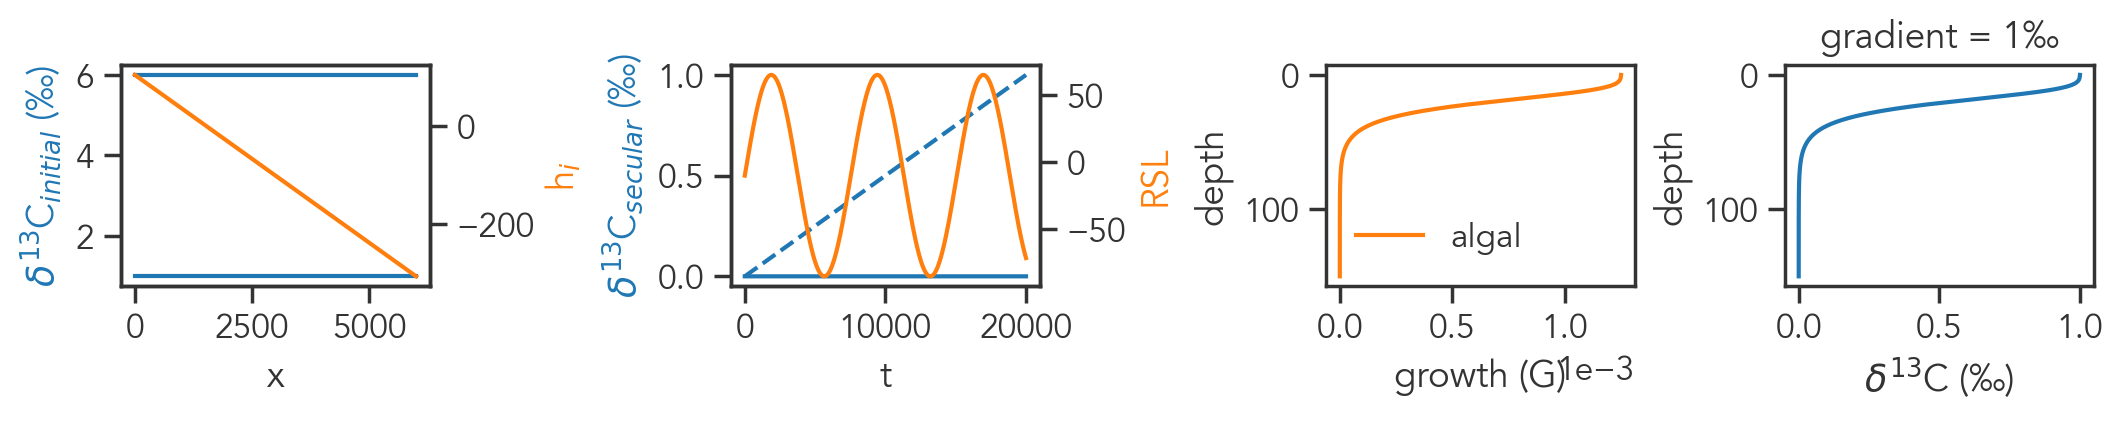

In [7]:
## Define h: initial topographic composition
h = -0.0685*x+105 # for xmax of 6000; slope chosen to match bahamas aspect ratio
#h = 200*jnp.cos(x/1850)-110 # 2200

## Define w: initial proxy composition
wi_p = jnp.ones_like(h)*6 # shallow value boundary condition for positive run
wi_n = jnp.ones_like(h)*1 # deep value boundary condition for negative run

# secular w array
sec_w_fun = lambda t: jnp.zeros_like(t)
sec_w_fun1 = lambda t: t/20000

# sea level curve array - want to simulate a range of magnitudes (HICE is inferred to be ~150m)
sl_fun = lambda t: 75*jnp.sin((t)/1200)-10 # simple version # 1400

fig,ax = plt.subplots(1,4,figsize=(10.5,2),layout='constrained')

# initial proxy and topography
ax[0].plot(x,wi_p,label='$\\delta^{13}$C$_{initial}$ (‰)',color='tab:blue') # showing index not actual units
ax[0].plot(x,wi_n,label='$\\delta^{13}$C$_{initial}$ (‰)',color='tab:blue') # showing index not actual units
axi = ax[0].twinx()
axi.plot(x,h,label='h$_i$',color='tab:orange') # showing index not actual units
ax[0].set_xlabel('x')
ax[0].set_ylabel('$\\delta^{13}$C$_{initial}$ (‰)',color='tab:blue')
axi.set_ylabel('h$_i$',color='tab:orange')

# proxy over time
ax[1].plot(t,sec_w_fun(t),color='tab:blue')
ax[1].plot(t,sec_w_fun1(t),color='tab:blue',ls='--')

ax[1].set_ylabel('$\\delta^{13}$C$_{secular}$ (‰)',color='tab:blue')
ax[1].set_xlabel('t');
axii = ax[1].twinx()
# sea level
axii.plot(t,sl_fun(t),color='tab:orange')
axii.set_ylabel('RSL',color='tab:orange')

## Growth Functions ##
## dummy depth data
z = np.linspace(1e-5,150,1000)

# functions for model -> dt seems to need to be 0 for both of them to work properly with the weighted average. otherwise get pelagic growth way too shallow than should be possible 
Dt_alg = 0 #5 # maybe this is a solution for a lag parameter
Dt_pel = 0.5
algal_growth = lambda x: bosscher_G(x,Gm=0.00125,out='growth',Dt=Dt_alg)
pelagic_growth = lambda x: bosscher_G(x,Io=0.00125,k=0.1,out='light',Dt=Dt_pel)  # here G is light curve scaled to Gmax which is 0.00125 here (for pelagic), np.trapz to max depth
#pelagic_growth = lambda x: bosscher_G(x,Io=0.00125,k=0.01,out='light',Dt=Dt_pel)  # here G is light curve scaled to Gmax which is 0.00125 here (for pelagic), np.trapz to max depth

# pelagic growth
#ax[2].plot(pelagic_growth(z),z,color='tab:blue',label='pelagic')
ax[2].plot(algal_growth(z),z,color='tab:orange',label='algal',ls='-')
#ax[2].plot(algal_growth(z),z,color='tab:purple',label='coral',ls='--')
ax[2].set_xlabel('growth (G)')
ax[2].legend(frameon=False)
ax[2].ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax[2].set_ylabel('depth')
ax[2].invert_yaxis()

# ~5‰ depth gradient
#depth_w_fun = lambda x: bosscher_G(x,out='growth',Gm=5,G_base=1,k=0.2) # can change k for how sharp the gradient is (lower = more gradual)
# can change Gm to shift gradient magnitude:
G_base_pos = 0 # minumum (deep) value; 1
Gm_pos = 1 # maximum (shallow) value; 5
G_base_neg = 6
Gm_neg = -5
print(f'gradient = {Gm_pos+1-G_base_pos}‰')
depth_w_fun_pos = lambda x: bosscher_G(x,out='growth',Gm=Gm_pos,G_base=G_base_pos,k=0.1)#,Ik=750) # can change k for how sharp the gradient is (lower = more gradual); 0.2. 0.4
#depth_w_fun_neg = lambda x: bosscher_G(x,out='growth',Gm=Gm_neg,G_base=G_base_neg,k=0.1)#,Ik=750) # can change k for how sharp the gradient is (lower = more gradual); 0.2. 0.4

ax[3].plot(depth_w_fun_pos(z),z)
#ax[3].plot(depth_w_fun_neg(z),z)
ax[3].set_title(f'gradient = {Gm_pos-G_base_pos}‰')
ax[3].invert_yaxis()
ax[3].set_xlabel('$\\delta^{13}$C (‰)')
ax[3].set_ylabel('depth')
#ax[3].set_xticks(np.arange(G_base_pos,Gm_pos+2));

# print RSL Fall Magnitude
rsl_mag = abs(max(sl_fun(t)) - min(sl_fun(t)))

sl_low = np.where(np.gradient(sl_fun(t))<0,sl_fun(t),np.nan)
sl_high = np.where(np.gradient(sl_fun(t))>0,sl_fun(t),np.nan)
rsl_mag_low = abs(np.nanmax(sl_low)-np.nanmin(sl_low))
rsl_mag_high = abs(np.nanmax(sl_high)-np.nanmin(sl_high))

print(f'RSL Fall Magnitude = {rsl_mag_low:.0f} m')
print(f'RSL Rise Magnitude = {rsl_mag_high:.0f} m')

# print height of model space
basin_height = abs(max(h)-min(h))
print(f'basin height = {basin_height:.2f}')

wi_m = jnp.ones_like(h)*sec_w_fun1(t)[0] # first secular value value boundary condition


## run models (4 here) and a version with time as w

- [x] fix boundary conditions
- [x] find way to colour-code the individual T-R cycle lines on basins
      

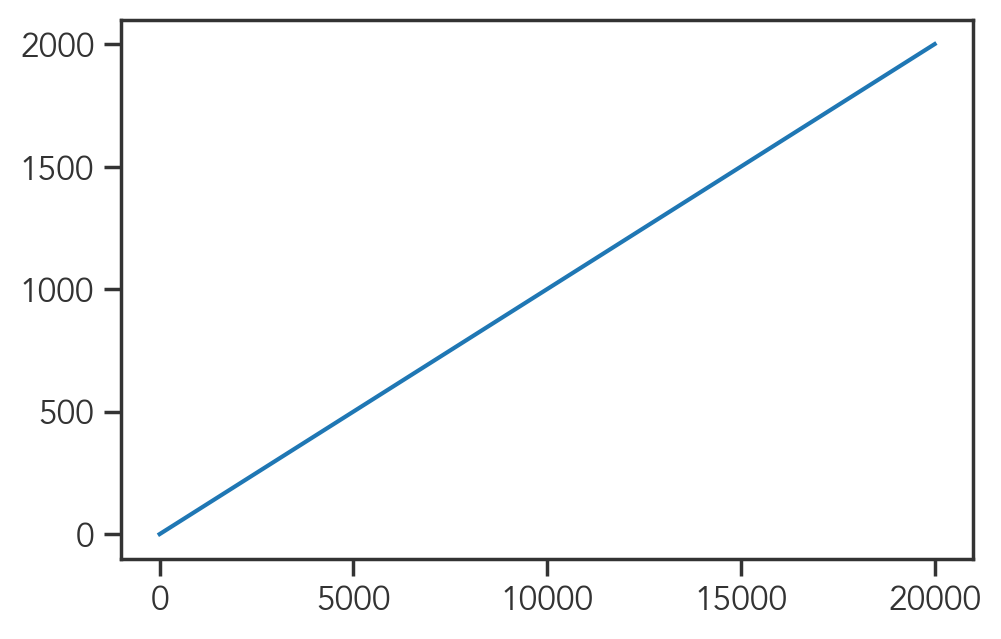

In [8]:
#sec_w_fun_sec1 = lambda t: t/5000 +1
sec_w_fun_sec1 = lambda t: t/10
plt.plot(t,sec_w_fun_sec1(t))

## Sept 25, 2024: we have determined that the "toggle" for eqn2 residual is insufficient. Closest way to show this is for a secular scenario (as am showing here) with expected values (im_t) shown. Basically just want the basin coloured by time and can overlay a value between 0 and 1 if I want

In [9]:
# wi_mm is time as w

# dictionary to store all outputs from each model run
outputs = {}

# parameters to vary between each run
st = [sec_w_fun1,sec_w_fun_sec1] # secular changes; fun is linear w (0-1), fun_sec1 is time (0-2000)
full = True # quick toggle for and erosion history

# loop over the two different scales (0 to 1, and 0 to 2000)
for idx,sec_var in enumerate(st):
    print(f'iteration {idx+1}')
    mod = run(params,model_desc = f'synthetic test method: {idx}',hi=h,wi=wi_m,wi_sec=True,sl_fun=sl_fun,sec_w_fun=sec_var,
              depth_w_fun=None,carb_growth=True,growth_fun_alg=algal_growth,growth_fun_coral=None,
              growth_fun_pel=None,pel_coef=0.1,alg_coef=8.5,coral_coef=10,conv_sig=20,plot_skip=1,
              plot_out=False,const_K=False,cmap='coolwarm',w_transport=True,w_set_erode=full,full_storage=False,figsize=(8,2))
    outputs[idx] = mod

iteration 1
calculated ymin,ymax = -391.00, 190.00
mean grid dy = 5.816e-01


running model: synthetic test method: 0_A0.1_ylen1000_2025-04-15 20:54:   0%|          | 0/2000 [00:00<?, ? co…

iteration 2
calculated ymin,ymax = -391.00, 190.00
mean grid dy = 5.816e-01


running model: synthetic test method: 1_A0.1_ylen1000_2025-04-15 21:01:   0%|          | 0/2000 [00:00<?, ? co…

In [10]:
# define max depth
max_depth = np.nanmax(outputs[0]['ds'])
print(f'max depth = {max_depth:.2f}')

# simple version with fewer facies and just depth ranges
facies_data = facies(max_depth)

# facies colours # my_pal
facies_colours = list(sns.color_palette('BrBG',n_colors=len(facies_data)+1).as_hex()) # add one as going to drop the white one
facies_colours.pop(5) # drop the white one # was 4
sns.color_palette(facies_colours) # look at the palette

## model outputs
mouts = {}
for i in range(len(outputs)):
    out = Model_output(**outputs[i],facies_data=facies_data,facies_colours=facies_colours,bc_filter=False,set_under_c='.3',im_ylen=5000,images=True)
    mouts[i] = out

max depth = 411.00


## Version with only lower panel components and binned colors based on 

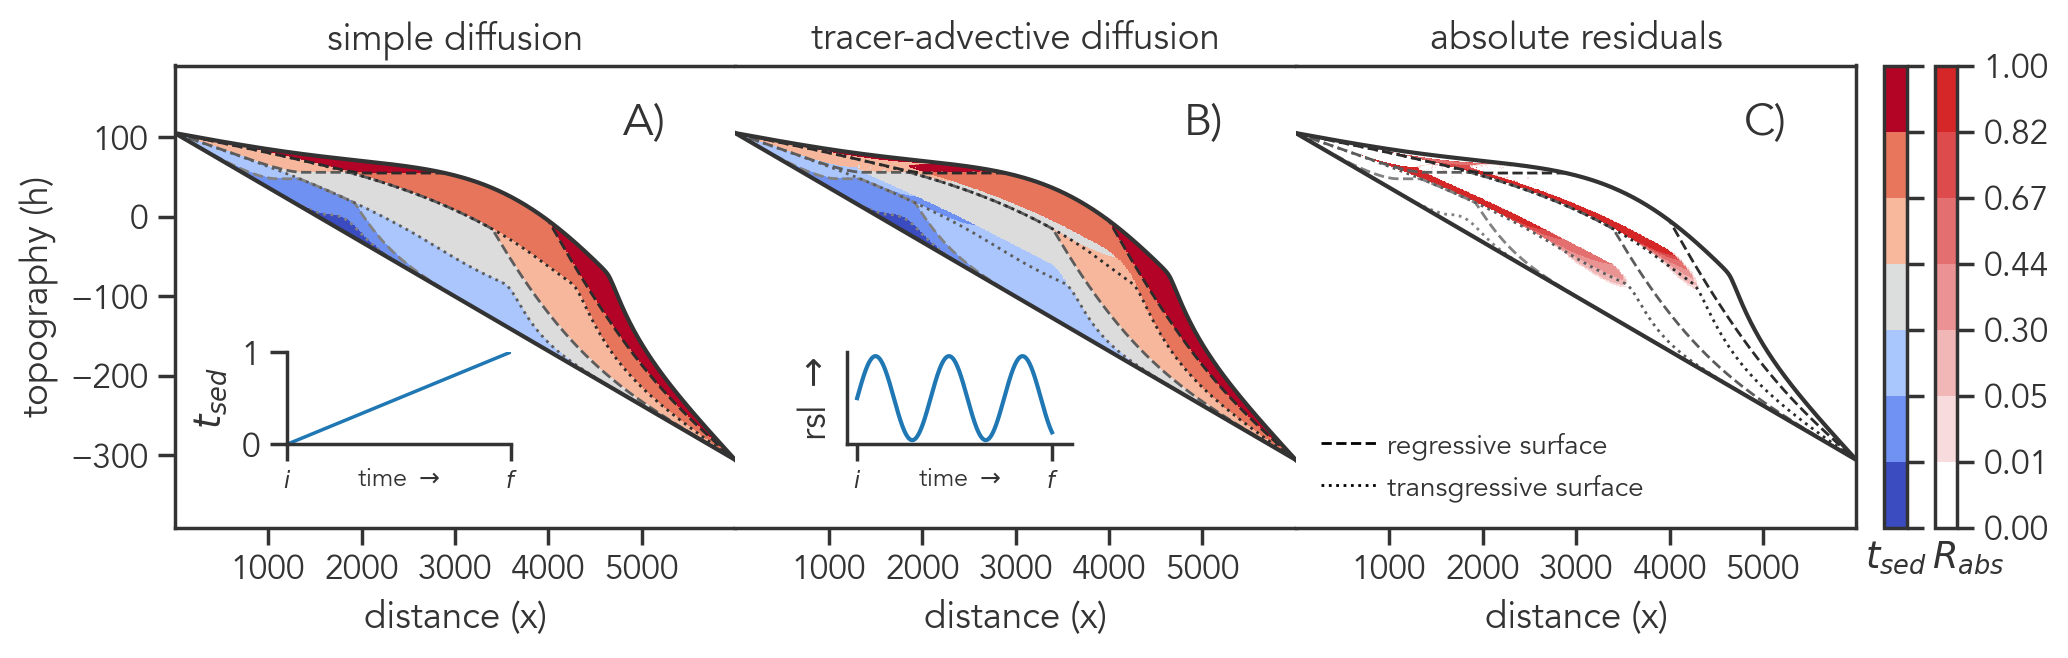

In [13]:
def figX(t_idx=params['total_n']-1,anim=False,ylen=1000,scatter=False,line=True,skip=0):
    """
    
    """
    mod = outputs[0]
    out = mouts[0]
    extent = out.extent
    
    if anim:
        tim,_ = mouts[0].im_plot(show='time',ylen=ylen,total=t_idx) # define time image
        wim,_ = mouts[0].im_plot(show='proxy',ylen=ylen,total=t_idx) # define time image
    else:
        tim = mouts[0].im_t
        wim = mouts[0].im_w
    # "equation 2 off": im_t; mouts[0] has everything in terms of 0-1 proxy, mouts[1] is in terms of time
    tw = sec_w_fun1(tim*params['dt']*params['compiled_steps']) # convert im_t to proxy values 0 to 1
    
    # calculate residual - defined as eq2 off - eq2 on
    res2 = norm01(abs(tw - wim)) # abs normalized to 0 and 1
    
    # order of target arrays
    arrays = [tw,wim,res2]
    
    # time version
    times = sorted(np.concatenate([out.reg_idx,out.tran_idx]))
    times.insert(0,0)
    # # Add an upper boundary to extend the last color properly
    times = np.append(times,times[-1]+(times[-1]-times[-2]))

    # convert temporal idx to proxy
    f = interp1d(t,sec_w_fun1(t))
    w_interp = f(times*10)
    w_interp[-1] = max(sec_w_fun1(t)) # replace end with max value so that it extends to full range of colorbar
    
    # all data saved in outputs and mouts
    #fig,ax = plt.subplot_mosaic('abc.d.e',figsize=(10,2.75),width_ratios=[1,1,1,0.05,0.04,0.05,0.04])#,layout='constrained') # 0.05,0.04,0.05,0.04; (10, 5.5)
    fig,ax = plt.subplot_mosaic('abc.d.e',figsize=(11.5,3),width_ratios=[1,1,1,0.05,0.04,0.05,0.04])#,layout='constrained') # 0.05,0.04,0.05,0.04; (10, 5.5)

    plt.subplots_adjust(wspace=0,hspace=0.075)
    
    axs = list(ax.keys())
    axs = [i for i in axs if i not in ['d','e']]
    
    imgs = []
    #colors = ['#d62728', 'w', '#1f77b4']
    #colors = ['#d62728', 'w', '.2']
    colors1 = ['w','tab:blue']
    colors2 = ['w','tab:red']
    colors3 = ['tab:blue','w','tab:red']
    
    ccmap1 = LinearSegmentedColormap.from_list('residuals_cmap', colors1)
    ccmap2 = LinearSegmentedColormap.from_list('residuals_cmap', colors2)
    
    ccmap1 = sns.color_palette('coolwarm', as_cmap=True)
    
    norm = BoundaryNorm(w_interp, ccmap1.N)
    
    for i in range(len(axs)):
        targ = arrays[i]
        cmap = ccmap1 if i<2 else ccmap2
        vmin = 0 
        norm = norm
        sm = imshow(targ,ax=ax[axs[i]],cmap=cmap,extent=extent,cbar=False,rasterized=True,norm=norm) # ,vmin=vmin,vmax=1
        imgs.append(sm)
        color = '.2'
        
        # custom colour gradient for each T-R package
        n_colors = max(len(out.tran_idx), len(out.reg_idx))
        dark_greys = sns.color_palette('Greys', n_colors=2*n_colors)[n_colors:]
        ax[axs[i]].set_prop_cycle(cycler('color',dark_greys))
    
        # plot T-R surfaces
        ax[axs[i]].plot(mod['x'],mod['beds_eroded'][out.reg_idx,:].T,alpha=1,ls='--',lw=1,label='reg dressive surface')#,color=color);\
        ax[axs[i]].plot(mod['x'],mod['beds_eroded'][out.tran_idx,:].T,alpha=1,ls=':',lw=1,label='transgressive surface')#,color=color);
    
        # plot initial and final beds
        ax[axs[i]].plot(mod['x'],mod['beds_eroded'][0].T,color='.2',alpha=1,ls='-',zorder=10000);

        # add current values as scatter
        if scatter:
            if t_idx < (params['total_n']-1)-skip and i < 2:
                ax[axs[i]].scatter(mod['x'], mod['beds'][t_idx], c=mod['proxy'][t_idx], marker='s', 
                                alpha=1, zorder=100, cmap=cmap, s=10, lw=0.15, edgecolor='k',vmin=np.nanmin(mod['proxy']),vmax=np.nanmax(mod['proxy']))
            else:
                ax[axs[i]].plot(mod['x'], mod['beds'][t_idx].T, color='.2', alpha=1, ls='-', zorder=10000)
        if line:
            ax[axs[i]].plot(mod['x'], mod['beds'][t_idx].T, color='.2', alpha=1, ls='-', zorder=10000)
        elif line==False and t_idx >= (params['total_n']-1)-skip:
            ax[axs[i]].plot(mod['x'], mod['beds'][t_idx].T, color='.2', alpha=1, ls='-', zorder=10000)
            

    # colorbars
    cbar1 = plt.colorbar(imgs[0],cax=ax['d'],orientation='vertical',location='right',aspect=50) # cax=ax['e']
    cbar2 = plt.colorbar(imgs[-1],cax=ax['e'],orientation='vertical',location='right',aspect=50) #ax=[ax['b'],ax['d']] #cax=ax['i']
    cbar2.ax.sharey(cbar1.ax)
    cbar1.ax.tick_params(labelright=False)  # Hides labels on cb2's y-axis
    
    for cb in [cbar1,cbar2]:
        cb.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        #cb.set_ticks([0,1])
        #cb.ax.tick_params(which='both', length=0)  # This removes both major and minor tick lines
    
    ax['d'].set_xlabel('$t_{sed}$')
    ax['e'].set_xlabel('$R_{abs}$') #$R_{abs}$
    ax['e'].xaxis.set_label_coords(1.5,-0.025)
    
    [ax[a].spines[['right']].set_visible(False) for a in ['a','b']]
    [ax[a].spines[['left']].set_visible(False) for a in ['b','c']]
    [ax[a].set_yticks([]) for a in ['b','c']]
    [ax[a].set_xticks(np.arange(1000,6000,1000)) for a in axs];
    #[ax[a].set_xlim(left=2000) for a in axs];
    
    ax['a'].set_ylabel('topography (h)')
    [ax[a].set_xlabel('distance (x)') for a in axs];
    
    # label abc...
    abc = [i+')' for i in string.ascii_uppercase[:3]]
    for i,j in zip(axs,abc):
        #axa = a.lower()
        ax[i].text(0.8,0.85,j,transform=ax[i].transAxes,fontsize=16)
    
    # rsl inset
    axi = ax['b'].inset_axes([0.2,0.18,0.4,0.2])
    axi.plot(mod['ts'],mod['rsl_strat'])
    axi.set_xlabel(r'time $\rightarrow$',fontsize=9,labelpad=-10)
    axi.set_xticks([0,max(t)],['$i$','$f$'],fontsize=8)
    axi.spines[['right','top']].set_visible(False)
    axi.set_ylabel(r'rsl $\rightarrow$')
    axi.set_yticks([])
    axi.set_xlim(right=22000)
    if anim:
        axi.plot(mod['ts'][t_idx],mod['rsl_strat'][t_idx],'r.') # plot where on rsl curve we are

    # secular inset
    axii = ax['a'].inset_axes([0.2,0.18,0.4,0.2])
    axii.spines[['right','top']].set_visible(False)
    lat = sec_w_fun1(t)
    axii.plot(t,lat,lw=1.25,ls='-',color='tab:blue')
    axii.set_xlim(0,max(t))
    axii.set_xticks([0,max(t)],['$i$','$f$'],fontsize=8)
    axii.set_xlabel(r'time $\rightarrow$',fontsize=9,labelpad=-10)
    axii.set_ylim(0,1)
    axii.set_ylabel('$t_{sed}$') #$w$
    if anim:
        axii.plot(mod['ts'][t_idx],sec_w_fun1(t_idx*10),'r.') # plot where on rsl curve we are

    
    # titles; renamed
    ax['a'].set_title('simple diffusion') # equation 2 off
    ax['b'].set_title('tracer-advective diffusion') # equation 2 on
    ax['c'].set_title('absolute residuals')
    
    # make legend
    el = [Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls='--',alpha=1,label='regressive surface',markerfacecolor='none', markersize=0),
          Line2D([0], [0],mew=0.65,lw=1, marker='v', color='k', ls=':',alpha=1,label='transgressive surface',markerfacecolor='none', markersize=0)]
    leg = ax['c'].legend(handles=el,loc=3,ncols=1,frameon=False,framealpha=1,fontsize=10,handletextpad=0.4,markerfirst=True)#,handlelength=0.75)

    return fig

# make paper version
fig = figX()
# save figure
fig.savefig(tex_fig_dir+'synth_comp_simpl_bin.pdf',format='pdf',dpi=300,bbox_inches='tight',transparent=True)#

### Version with animation

In [9]:
def animate_fig(ylen=250, model_name=None,frames_dir=None, ani_dir=None, output_format='mp4', fps=15, skip=20,scatter=True,line=False):
    """
    animate the methods figure
    """
    # define model parameters
    mod = outputs[0]
    
    for i in [':',' ']: # ffmpeg breaks from the colon and space in the time
        model_name = model_name.replace(i,'_')
        # clean up old jpgs
        [os.remove(frames_dir+file) for file in os.listdir(frames_dir) if file.endswith('.jpg')]
    end = params['total_n']

    for idx in range(1,end):
        if idx%skip==0:
            # don't want eroded for these
            bed = mod['beds'][idx]
            proxy = mod['proxy'][idx]
        
            # figure
            fig = figX(anim=True,t_idx=idx,ylen=ylen,scatter=scatter,skip=skip,line=line)

            # save frame
            fig.savefig(f'{frames_dir}frame{str(idx).zfill(6)}.jpg',dpi=300) 
            print(f'\rprocessing frame {idx} / {end}',end='')
            plt.close('all')

    command = (
    f'ffmpeg -y -framerate {fps} -pattern_type glob '
    f'-i "{frames_dir}/*.jpg" -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" ' # the space at the end is important
    f'-c:v libx264 -r 15 -y -vb 20M {ani_dir+model_name}.{output_format} -loglevel quiet ')
    !{command} # works in jupyter
    #os.system(command) # works from py file
    # clean up old jpgs for space saving
    [os.remove(frames_dir+file) for file in os.listdir(frames_dir) if file.endswith('.jpg')]
    print('\nprocessing completed')

In [11]:
# model_name = outputs[0]['name']+'method_ani' # for some reason needs 'name'
# fig_dir_ani = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport/current_notebooks/figs/'
# frames_dir = fig_dir_ani+'animations/frames/'
# ani_dir = fig_dir_ani+'animations/mp4/'
# animate_fig(ylen=500, model_name=model_name,frames_dir=frames_dir,ani_dir=ani_dir,scatter=False,line=False,skip=25)

### Figure for Exit Seminar
- when animate, going to make a janky version that uses sea level to determine whether to use eroded or not version of image

In [649]:
def figY1(t_idx,lc=2760,ylen=500,anim=False,skip=1):
        
    mod = outputs[0]
    out = mouts[0]
    rsl = out.rsl_strat
    extent = out.extent

    # if anim:
    #     if rsl[t_idx + 1] > rsl[t_idx]:
    #         btarg='full'
    #     else:
    #         btarg='eroded'
    # else:
    #     btarg='eroded'

    btarg='eroded'
    
    wim,_ = out.im_plot(show='depth',ylen=ylen,total=t_idx,btarg=btarg) # define time image
    him,_ = out.im_plot(show='topo',ylen=ylen,total=t_idx,btarg=btarg) # define time image
    fim = out.map_facies(wim,extent,ter_thresh=-0.2)
    
    fig,ax = plt.subplots(1,2,figsize=(8,4),width_ratios=[1,0.15],layout='constrained')
    
    ax[0].imshow(fim,aspect='auto',origin='lower',extent=extent,cmap=out.cmap,zorder=10000)
    ax[0].plot(mod['x'],mod['beds'][0],color='.2',alpha=1,ls='-',lw=2,zorder=20000);
    ax[0].plot(mod['x'],mod['beds'][t_idx],color='.2',alpha=1,ls='-',lw=2,zorder=20000);
    
    # strat col
    locs = [lc]
    locs2 = out.Nx_toX(locs, out='Nx')
    ax[0].axvline(locs[0],zorder=0,ls='--',color='.2')

    if out.beds[t_idx, locs2[0]] > out.beds[0,locs2[0]]:
        targ_val, new_y_val, y_min, y_max,seq_y = out.strat_col_im(locs2,targ=wim,htarg=him,ftarg=fim,scale=False,out=True,plot=True,ax=ax[1],x_axis=True,seq_bounds=False)

        # if 595<=t_idx<1340:
        #     #for sb in seq_y[0]:
        #     # ax[1].plot(1.2,sb,marker='<',color='tab:red',zorder=1000,markersize=2.5)
        #     ax[1].axhline(seq_y[0][1],color='tab:orange',zorder=1000,ls='--',lw=2)
        # elif t_idx>1340:
        #     for sb in seq_y[0]:
        #         ax[1].axhline(sb,color='tab:orange',zorder=1000,ls='--',lw=2)

    # plot T-R surfaces
    su = np.concatenate([out.tran_idx[:],out.reg_idx[:]])
        
    # Generate the available timesteps based on the skip value
    available_t_idx = np.arange(1, end, skip)
    
    # Find the closest available t_idx for each target time
    closest_t_idx = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in su])
    
    # Ensure uniqueness (remove duplicates if any)
    closest_t_idx = np.unique(closest_t_idx)
    su1 = [int(i) for i in closest_t_idx]

    reg_close = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in out.reg_idx[:]])
    tran_close = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in out.tran_idx[:]])

    # for s in su1:
    #     if s<=t_idx:
    #         if s in reg_close:
    #             if s < reg_close[-1]:
    #                 var = 'beds'
    #             else:
    #                 var = 'beds_eroded' # actually easier to see in animation if i just leave them overlapping and can explain
    #             ax[0].plot(mod['x'],mod[var][s,:].T,alpha=1,ls='-',lw=2,label='regressive surface',zorder=1000000,color='tab:orange');
    #         elif s in tran_close:
    #            ax[0].plot(mod['x'],mod['beds_eroded'][s,:].T,alpha=1,ls='--',lw=2,label='transgressive surface',zorder=100000,color='tab:orange');

            # only labeling transgressive surfaces, as pretty hard to read otherwise, and these are the most erosive
            # if s in tran_close:
            #     ax[0].plot(mod['x'],mod['beds_eroded'][s,:].T,alpha=1,ls='-',lw=2,label='transgressive surface',zorder=100000,color='tab:orange');
    
    # clean up
    ax[0].spines[['top','right']].set_visible(False)
    ax[0].set_ylim(-300,150)
    ax[0].set_yticks(np.arange(-300,300,100));
    ax[1].set_ylim(2,150)
    ax[0].set_ylabel('topography (h)')
    ax[0].set_xlabel('distance (x)')
    ax[1].set_ylabel('stratigraphic height')

    # clean
    ax[1].set_xlim(0,1)
    ax[1].set_xticks([0,0.5,1])
    ax[1].spines[['top','right']].set_visible(False)
    ax[1].set_xlabel('grain size')

    # add rsl 
    ax[0].axhline(rsl[t_idx],color='dodgerblue',ls=':')

    axi = ax[0].inset_axes([0.1,0.1,0.3,0.3])
    axi.plot(out.ts[:],out.sl,color='tab:red')
    axi.plot(out.ts[t_idx],out.sl[t_idx],'ko',clip_on=False,markerfacecolor='w')
    axi.set_yticks([])
    axi.set_yticks([])
    axi.set_ylabel(r'shore $\rightarrow$ deep')
    #axi.text(0.8,0,2,f'{t_idx}',transform=axi.transAxes)
    ax[1].set_title(f'{t_idx}')

    # fill under to mark sequences
    tc1 = [int(i) for i in tran_close]
    rc1 = [int(i) for i in reg_close]
    rcol = 'tab:blue'
    tcol = 'tab:red'
    ax[0].fill_between(out.x,out.beds_eroded[0],mod['beds_eroded'][rc1[0],:].T,zorder=10000,color=tcol,alpha=0.6)
    ax[0].fill_between(out.x,mod['beds_eroded'][rc1[0],:],mod['beds_eroded'][tc1[1],:].T,zorder=10000,color=rcol,alpha=0.6)
    ax[0].fill_between(out.x,mod['beds_eroded'][tc1[1],:],mod['beds_eroded'][rc1[1],:].T,zorder=10000,color=tcol,alpha=0.6)
    ax[0].fill_between(out.x,mod['beds_eroded'][rc1[1],:],mod['beds_eroded'][tc1[2],:].T,zorder=10000,color=rcol,alpha=0.6)
    ax[0].fill_between(out.x,mod['beds_eroded'][tc1[2],:],mod['beds_eroded'][rc1[2],:].T,zorder=10000,color=tcol,alpha=0.6)
    ax[0].fill_between(out.x,mod['beds_eroded'][rc1[2],:],mod['beds_eroded'][-1,:].T,zorder=10000,color=rcol,alpha=0.6)

    # mark on column
    for i,j in zip(seq_y[0],seq_y[1]):
        ax[1].axhline(i,color=tcol,zorder=1000,ls='--',lw=2)
        ax[1].axhline(j,color=rcol,zorder=1000,ls='--',lw=2)

    return fig

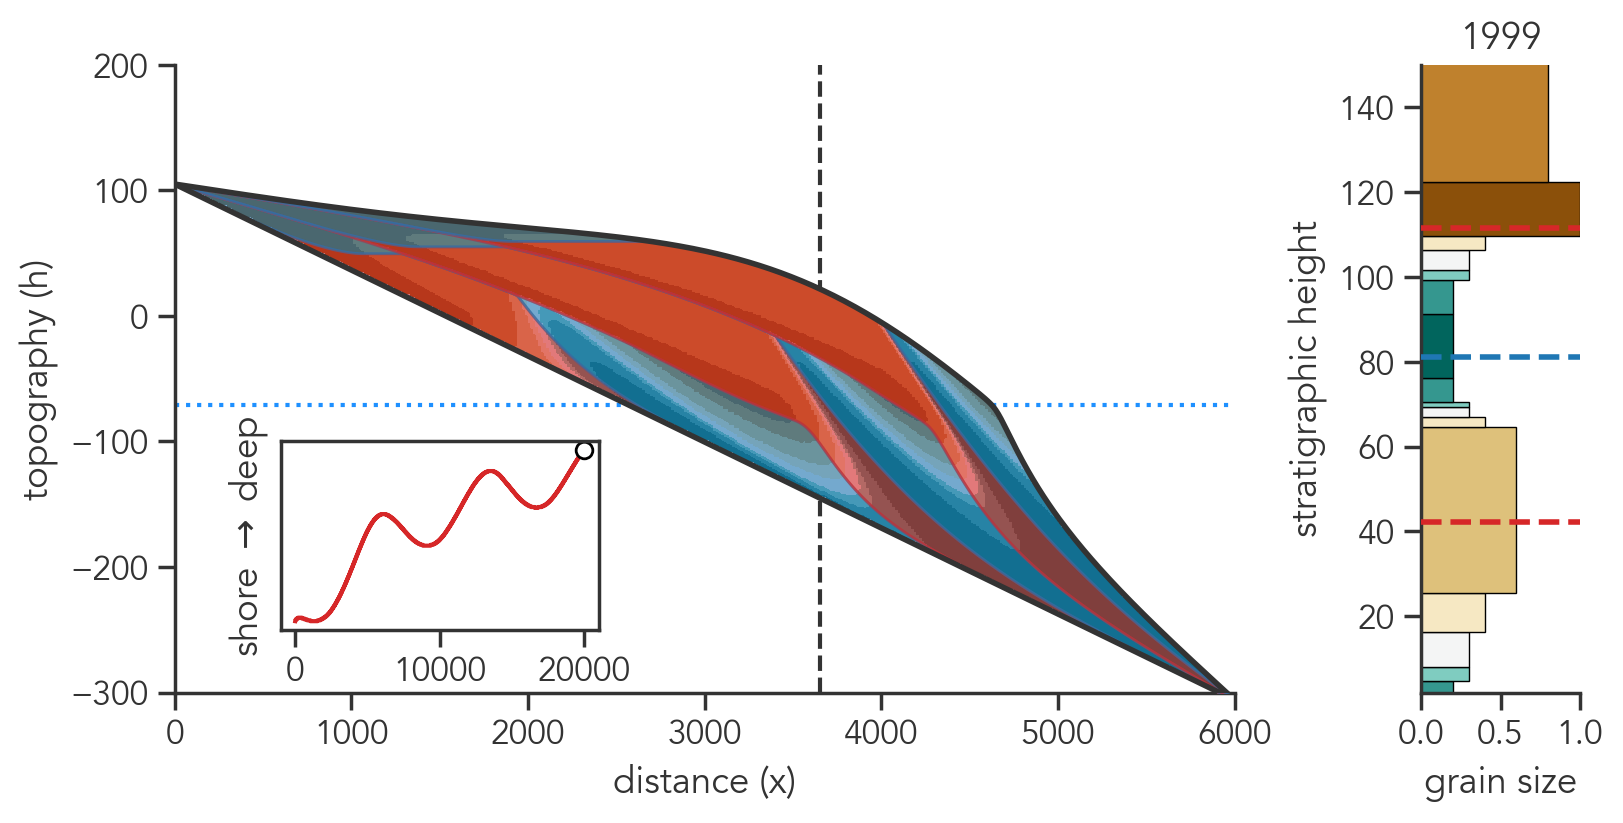

In [651]:
fig = figY1(1999,lc=3650,ylen=500,skip=22)
fig.savefig(sem_dir+'/model/seqs.png',format='png',dpi=300,bbox_inches='tight',transparent=True)

In [660]:
def figY(t_idx,lc=2760,ylen=500,anim=False,skip=1):
        
    mod = outputs[0]
    out = mouts[0]
    rsl = out.rsl_strat
    extent = out.extent

    # if anim:
    #     if rsl[t_idx + 1] > rsl[t_idx]:
    #         btarg='full'
    #     else:
    #         btarg='eroded'
    # else:
    #     btarg='eroded'

    btarg='eroded'
    
    wim,_ = out.im_plot(show='depth',ylen=ylen,total=t_idx,btarg=btarg) # define time image
    him,_ = out.im_plot(show='topo',ylen=ylen,total=t_idx,btarg=btarg) # define time image
    fim = out.map_facies(wim,extent,ter_thresh=-0.2)
    
    fig,ax = plt.subplots(1,2,figsize=(8,4),width_ratios=[1,0.15],layout='constrained')
    
    ax[0].imshow(fim,aspect='auto',origin='lower',extent=extent,cmap=out.cmap,zorder=10000)
    ax[0].plot(mod['x'],mod['beds'][0],color='.2',alpha=1,ls='-',lw=2,zorder=10000);
    ax[0].plot(mod['x'],mod['beds'][t_idx],color='.2',alpha=1,ls='-',lw=2,zorder=10000);
    
    # strat col
    locs = [lc]
    locs2 = out.Nx_toX(locs, out='Nx')
    ax[0].axvline(locs[0],zorder=0,ls='--',color='.2')

    if out.beds[t_idx, locs2[0]] > out.beds[0,locs2[0]]:
        targ_val, new_y_val, y_min, y_max,seq_y = out.strat_col_im(locs2,targ=wim,htarg=him,ftarg=fim,scale=False,out=True,plot=True,ax=ax[1],x_axis=True,seq_bounds=False)

        if 595<=t_idx<1340:
            #for sb in seq_y[0]:
            # ax[1].plot(1.2,sb,marker='<',color='tab:red',zorder=1000,markersize=2.5)
            ax[1].axhline(seq_y[0][1],color='tab:orange',zorder=1000,ls='--',lw=2)
        elif t_idx>1340:
            for sb in seq_y[0]:
                ax[1].axhline(sb,color='tab:orange',zorder=1000,ls='--',lw=2)

    # plot T-R surfaces
    su = np.concatenate([out.tran_idx[1:],out.reg_idx[1:]])
        
    # Generate the available timesteps based on the skip value
    available_t_idx = np.arange(1, end, skip)
    
    # Find the closest available t_idx for each target time
    closest_t_idx = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in su])
    
    # Ensure uniqueness (remove duplicates if any)
    closest_t_idx = np.unique(closest_t_idx)
    su1 = [int(i) for i in closest_t_idx]

    reg_close = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in out.reg_idx[1:]])
    tran_close = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in out.tran_idx[1:]])

    for s in su1:
        if s<=t_idx:
            # if s in reg_close:
            #     if s < reg_close[-1]:
            #         var = 'beds'
            #     else:
            #         var = 'beds' # actually easier to see in animation if i just leave them overlapping and can explain
            #     ax[0].plot(mod['x'],mod[var][s,:].T,alpha=1,ls='--',lw=2,label='regressive surface',zorder=1000000,color='tab:orange');
            # elif s in tran_close:
            #    ax[0].plot(mod['x'],mod['beds_eroded'][s,:].T,alpha=1,ls=':',lw=2,label='transgressive surface',zorder=100000,color='tab:orange');

            # only labeling transgressive surfaces, as pretty hard to read otherwise, and these are the most erosive
            if s in tran_close:
                ax[0].plot(mod['x'],mod['beds_eroded'][s,:].T,alpha=1,ls='-',lw=2,label='transgressive surface',zorder=100000,color='tab:orange');
    
    # clean up
    ax[0].spines[['top','right']].set_visible(False)
    ax[0].set_ylim(-300,150)
    ax[0].set_yticks(np.arange(-300,300,100));
    ax[1].set_ylim(2,150)
    ax[0].set_ylabel('topography (h)')
    ax[0].set_xlabel('distance (x)')
    ax[1].set_ylabel('stratigraphic height')

    # clean
    ax[1].set_xlim(0,1)
    ax[1].set_xticks([0,0.5,1])
    ax[1].spines[['top','right']].set_visible(False)
    ax[1].set_xlabel('grain size')

    # add rsl 
    ax[0].axhline(rsl[t_idx],color='dodgerblue',ls=':')

    axi = ax[0].inset_axes([0.1,0.1,0.3,0.3])
    axi.plot(out.ts[:],rsl,color='tab:red')
    axi.plot(out.ts[t_idx],rsl[t_idx],'ko',clip_on=False,markerfacecolor='w')
    axi.set_yticks([])
    axi.set_yticks([])
    #axi.set_ylabel(r'shore $\rightarrow$ deep')
    #axi.text(0.8,0,2,f'{t_idx}',transform=axi.transAxes)
    ax[1].set_title(f'{t_idx}')

    return fig

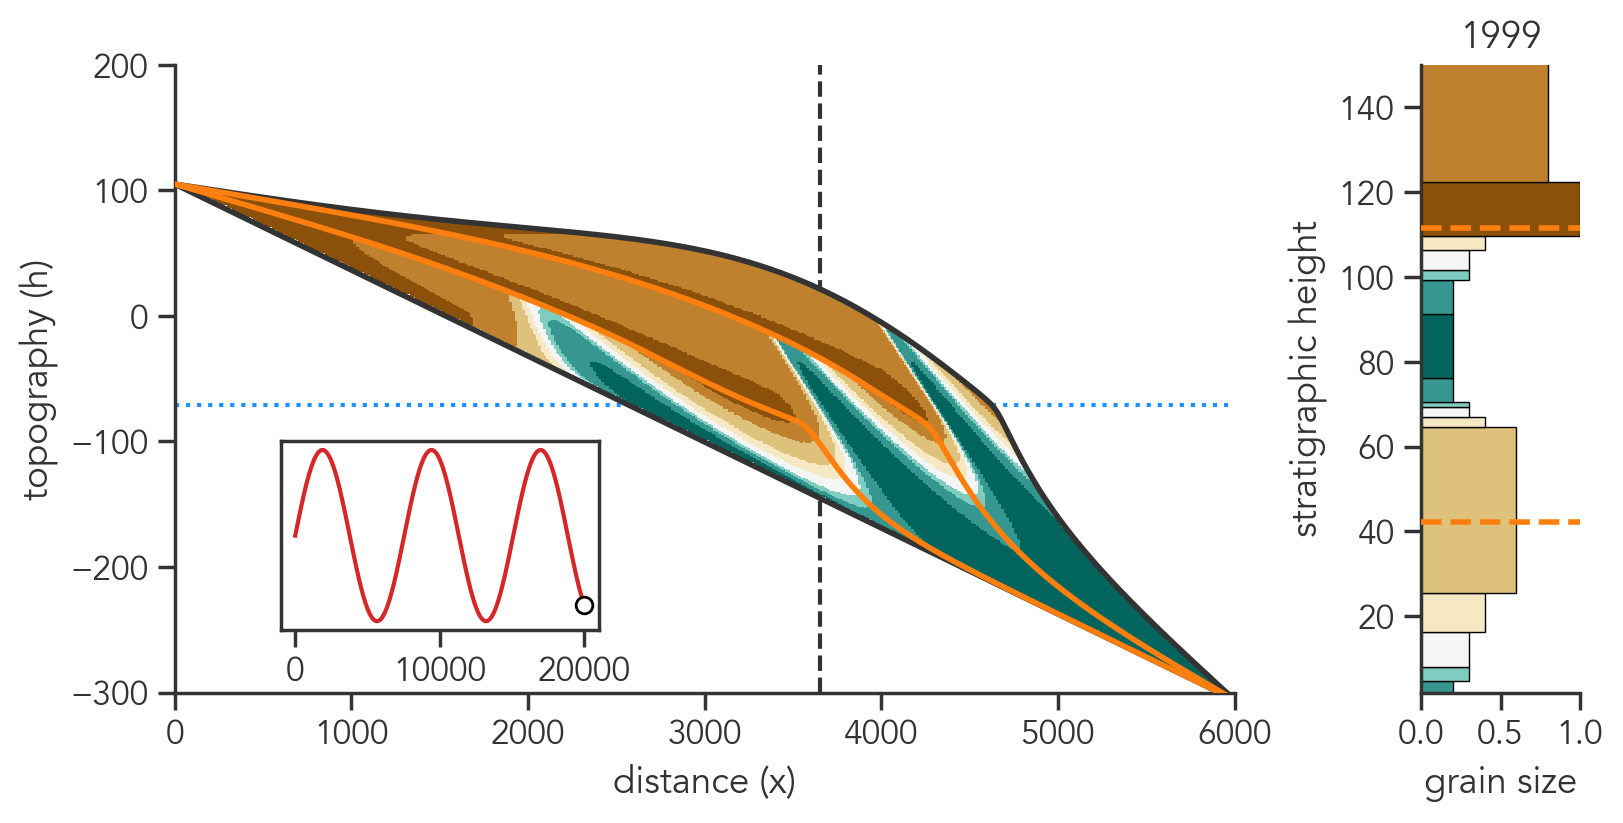

In [661]:
fig = figY(1999,lc=3650,ylen=500,skip=22)
#fig.savefig(sem_dir+'/model/seqs.png',format='png',dpi=300,bbox_inches='tight',transparent=True)

In [732]:
def figZ(t_idx,lc=2760,ylen=500,anim=False,skip=1):
        
    mod = outputs[0]
    out = mouts[0]
    rsl = out.rsl_strat
    extent = out.extent

    btarg='eroded'
    
    wim,_ = out.im_plot(show='depth',ylen=ylen,total=t_idx,btarg=btarg) # define time image
    him,_ = out.im_plot(show='topo',ylen=ylen,total=t_idx,btarg=btarg) # define time image
    fim = out.map_facies(wim,extent,ter_thresh=-0.2)
    
    fig,ax = plt.subplots(1,2,figsize=(8,4),width_ratios=[1,0.15],layout='constrained')
    
    ax[0].imshow(fim,aspect='auto',origin='lower',extent=extent,cmap=out.cmap,zorder=10000)
    ax[0].plot(mod['x'],mod['beds'][0],color='.2',alpha=1,ls='-',lw=2,zorder=10000);
    ax[0].plot(mod['x'],mod['beds'][t_idx],color='.2',alpha=1,ls='-',lw=2,zorder=10000);
    
    # strat col
    locs = [lc]
    locs2 = out.Nx_toX(locs, out='Nx')
    ax[0].axvline(locs[0],zorder=0,ls='--',color='.2')

    if out.beds[t_idx, locs2[0]] > out.beds[0,locs2[0]]:
        targ_val, new_y_val, y_min, y_max,seq_y = out.strat_col_im(locs2,targ=wim,htarg=him,ftarg=fim,scale=False,out=True,plot=True,ax=ax[1],x_axis=True,seq_bounds=False)
        #print(seq_y)
        if t_idx>880:
            ax[1].axhline(seq_y[1][1],color='tab:orange',zorder=1000,ls='--',lw=2)

    # plot T-R surfaces
    su = np.concatenate([out.tran_idx,out.reg_idx])
        
    # Generate the available timesteps based on the skip value
    available_t_idx = np.arange(1, end, skip)
    
    # Find the closest available t_idx for each target time
    closest_t_idx = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in su])
    
    # Ensure uniqueness (remove duplicates if any)
    closest_t_idx = np.unique(closest_t_idx)
    su1 = [int(i) for i in closest_t_idx]

    reg_close = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in out.reg_idx])
    tran_close = np.array([available_t_idx[np.abs(available_t_idx - t).argmin()] for t in out.tran_idx[1:]])

    for s in su1:
        if s<=t_idx:
            # only labeling transgressive surfaces, as pretty hard to read otherwise, and these are the most erosive
            if s in reg_close: # use eroded if transgressions and not eroded for regressions
                ax[0].plot(mod['x'],mod['beds'][s,:].T,alpha=1,ls='-',lw=2,label='transgressive surface',zorder=100000,color='tab:orange');
    
    # clean up
    ax[0].spines[['top','right']].set_visible(False)
    ax[0].set_ylim(-300,150)
    ax[0].set_yticks(np.arange(-300,300,100));
    ax[1].set_ylim(2,150)
    ax[0].set_ylabel('topography (h)')
    ax[0].set_xlabel('distance (x)')
    ax[1].set_ylabel('stratigraphic height')

    # clean
    ax[1].set_xlim(0,1)
    ax[1].set_xticks([0,0.5,1])
    ax[1].spines[['top','right']].set_visible(False)
    ax[1].set_xlabel('grain size')

    # add rsl 
    ax[0].axhline(rsl[t_idx],color='dodgerblue',ls=':')

    axi = ax[0].inset_axes([0.1,0.1,0.3,0.3])
    axi.plot(out.ts[:],rsl,color='tab:red')
    axi.plot(out.ts[t_idx],rsl[t_idx],'ko',clip_on=False,markerfacecolor='w')
    axi.set_yticks([])
    axi.set_yticks([])
    #axi.set_ylabel(r'shore $\rightarrow$ deep')
    #axi.text(0.8,0,2,f'{t_idx}',transform=axi.transAxes)
    ax[1].set_title(f'{t_idx}')

    return fig

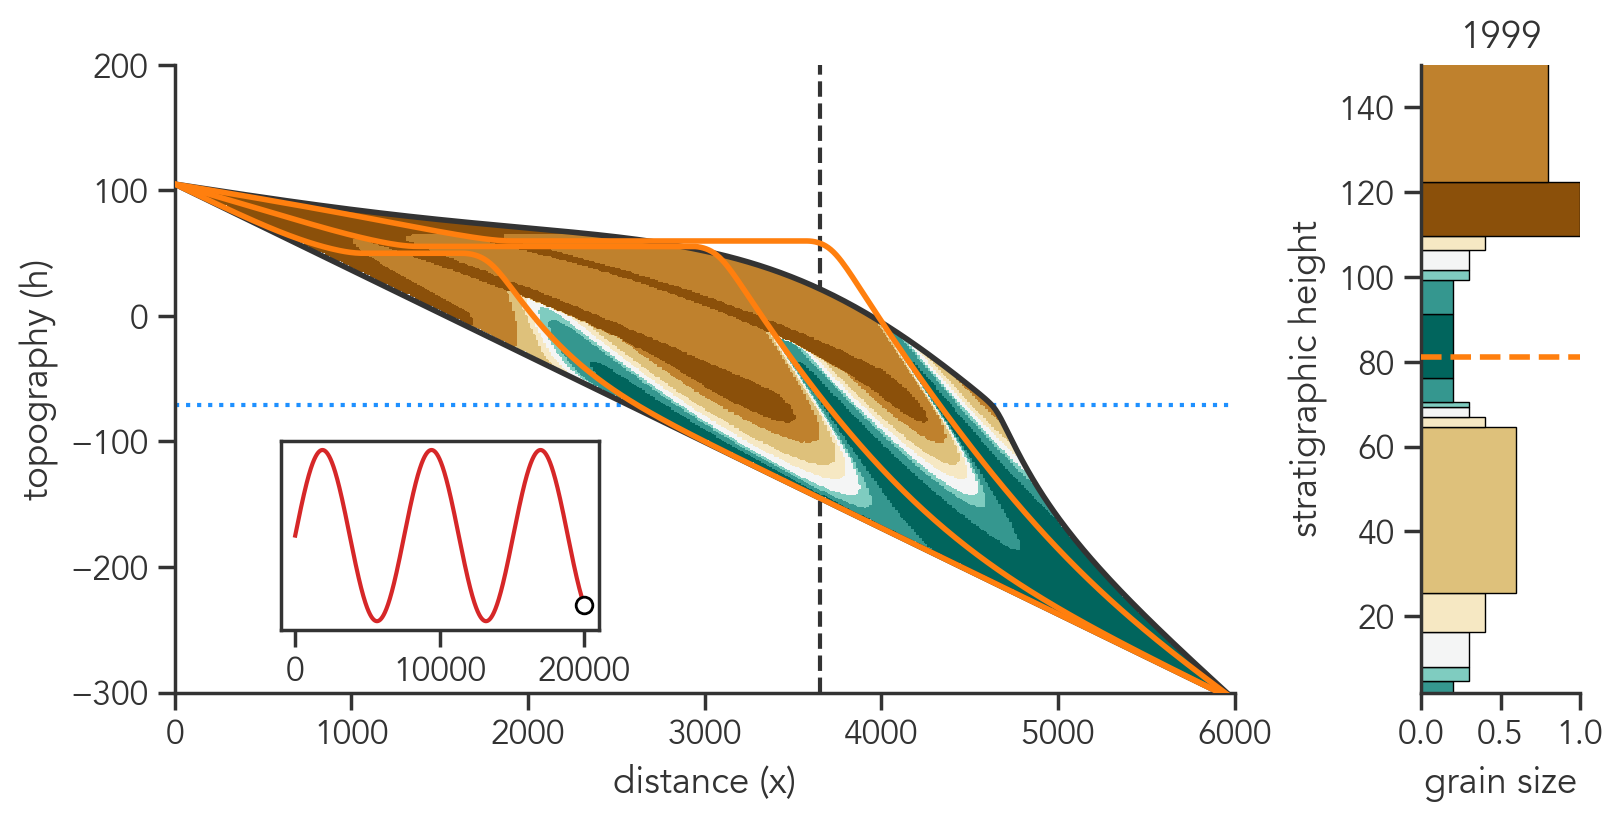

In [733]:
fig = figZ(1999,lc=3650,ylen=500,skip=22)
#fig.savefig(sem_dir+'/model/seqs2.png',format='png',dpi=300,bbox_inches='tight',transparent=True)

In [727]:
def animate_fig(ylen=250, lc=2760, model_name=None,frames_dir=None, ani_dir=None, output_format='mp4', fps=15, skip=20,scatter=True,line=False):
    """
    animate the methods figure
    """
    # define model parameters
    mod = outputs[0]
    
    for i in [':',' ']: # ffmpeg breaks from the colon and space in the time
        model_name = model_name.replace(i,'_')
        # clean up old jpgs
        [os.remove(frames_dir+file) for file in os.listdir(frames_dir) if file.endswith('.jpg')]
    end = params['total_n']

    for idx in range(1,end):
        if idx%skip==0:

            # figure
            #fig = figY(t_idx=idx,lc=lc,ylen=ylen,anim=True,skip=skip)
            fig = figZ(t_idx=idx,lc=lc,ylen=ylen,anim=True,skip=skip)

            # save frame
            fig.savefig(f'{frames_dir}frame{str(idx).zfill(6)}.jpg',dpi=300,transparent=True) 
            print(f'\rprocessing frame {idx} / {end}',end='')
            plt.close('all')

    command = (
    f'ffmpeg -y -framerate {fps} -pattern_type glob '
    f'-i "{frames_dir}/*.jpg" -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" ' # the space at the end is important
    f'-c:v libx264 -r 15 -y -vb 20M {ani_dir+model_name}.{output_format} -loglevel quiet ')
    !{command} # works in jupyter
    #os.system(command) # works from py file
    # clean up old jpgs for space saving
    [os.remove(frames_dir+file) for file in os.listdir(frames_dir) if file.endswith('.jpg')]
    print('\nprocessing completed')

In [728]:
model_name = outputs[0]['name']+'exit4' # for some reason needs 'name'
fig_dir_ani = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport/current_notebooks/figs/'
frames_dir = fig_dir_ani+'animations/frames/'
ani_dir = fig_dir_ani+'animations/mp4/'
animate_fig(ylen=500, lc=3650,model_name=model_name,frames_dir=frames_dir,ani_dir=ani_dir,scatter=False,line=False,skip=20)

processing frame 100 / 2000

/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport/output.py:403: RuntimeWarning: All-NaN slice encountered
  y_min,y_max = np.nanmin(htarg[:,loc]),np.nanmax(htarg[:,loc])


processing frame 120 / 2000

/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport/output.py:403: RuntimeWarning: All-NaN slice encountered
  y_min,y_max = np.nanmin(htarg[:,loc]),np.nanmax(htarg[:,loc])


processing frame 140 / 2000

...

processing frame 400 / 2000

/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport/utils.py:174: RuntimeWarning: invalid value encountered in scalar divide
  norm_y = y_min+(y_max-y_min)*y/(array_length-1)
/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport/utils.py:183: RuntimeWarning: invalid value encountered in scalar divide
  norm_topo = ((value-old_min)/(old_max-old_min))*(new_max-new_min)+new_min


processing frame 1980 / 2000

/Users/cvanwieren/anaconda3/envs/jax_env/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()



processing completed


# Working

In [ ]:
l = sns.color_palette('tab20',n_colors=8).as_hex()#,n_colors=len(w_interp))
l = [l[i] for i in [-1,-2,1,0,3,2,5,4]]
l

In [ ]:
lims = (0,1999,1)
@interact(idx=lims)
def f(idx):
    sea_level = mod['rsl_strat'][idx]
    marine_K = params['marine_K']
    land_K = params['land_K']
    smoothness = params['smooth_K']
    h_half = mod['beds'][idx,:]
    plt.title(f'{smoothness},{marine_K},{land_K}')
    #smoothness = 10
    plt.gca().axhline(sea_level,label='rsl')
    plt.plot(h_half,color='k',label='h')
    plt.legend(loc=1)
    K = ((-1 * np.tanh((h_half - sea_level)*1/smoothness) * (marine_K - land_K) / 2) + (land_K + marine_K) / 2)
    axi = plt.gca().twinx()
    axi.plot(K,color='tab:red',label='K');
    axi.legend(loc=3)

## animations

In [12]:
# m_idx = 2
# m_targ = mouts[m_idx]
# model_name = outputs[m_idx]['name']+'test' # for some reason needs 'name'
# fig_dir_ani = '/Users/cvanwieren/Library/CloudStorage/Dropbox/GitHub/sed_transport/sed_transport/current_notebooks/figs/'
# frames_dir = fig_dir_ani+'animations/frames/'
# ani_dir = fig_dir_ani+'animations/mp4/'

# m_targ.animate_w(ylen=250, mp4=True, model_name=model_name,norm=None,show='proxy',shore_targ='beds',tol=2,
#                    frames_dir=frames_dir, ani_dir=ani_dir,fps=15, skip=10,surfaces=True, figsize=(8,3.5), pal='coolwarm')

In [13]:
# m_idx = 0
# m_targ = mouts[m_idx]
# model_name = outputs[m_idx]['name']+'eqn2off' # for some reason needs 'name'

# m_targ.animate_w(ylen=250, mp4=True, model_name=model_name,norm=None,show='proxy',shore_targ='beds',tol=2,
#                    frames_dir=frames_dir, ani_dir=ani_dir,fps=15, skip=10,surfaces=True, figsize=(8,3.5), pal='coolwarm')